<h1><center>CMSE 381 Project</center></h1>
<h3><center>Siddak Marwaha</center></h3>
<h3><center>Datasets: Real Estate Valuation, Poker Hand</center></h3>

# 1. Regression on Real Estate Valuation

### Description of the data

The Real Estate Valuation dataset comprises historical data on real estate transactions from the Sindian District of New Taipei City, Taiwan. This dataset is suitable for regression as it focuses on predicting the house price (target variable) based on a set of features related to the property and location.

- Dataset Characteristics:
    - Type: Multivariate
    - Subject Area: Business / Real Estate
    - Associated Task: Regression
    - Data Format: Numerical (Integer and Real values)
    - Number of Instances: 414 records
    - Number of Features: 6 (excluding the target variable)
    
    
- Features and Target Variable:
    - No (int; feature): Sequential ID number for each record.	
    - X1 transaction date (float; feature): The date of the real estate transaction, represented as a fractional year (e.g., 2013.250 = March 2013). Unit - Year
    - X2 house age (float; feature): Age of the house in years at the time of sale.	Unit - Year
    - X3 distance to the nearest MRT station (float; feature): Distance from the property to the nearest MRT (subway) station. Unit - Meter
    - X4 number of convenience stores (int; feature): Number of convenience stores in the living circle on foot.
    - X5 latitude (float; feature):	Geographic coordinate, latitude. Unit - Degree
    - X6 longitude (float; feature): Geographic coordinate, longitude. Unit - Degree
    - Y house price of unit area (float; target): Price of the house per unit area. Unit - 10000 New Taiwan Dollar/Ping, where Ping is a local unit, 1 Ping = 3.3 meter squared	

### Standard Imports

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree


### EDA

In [2]:
real_estate = pd.read_excel('Real estate valuation data set.xlsx')
real_estate.shape

(414, 8)

In [3]:
real_estate.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1


In [4]:
real_estate.describe()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,207.500000,2013.148953,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,119.655756,0.281995,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,1.000000,2012.666667,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,104.250000,2012.916667,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,207.500000,2013.166667,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,310.750000,2013.416667,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,414.000000,2013.583333,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


In [5]:
# since we don't need the ID for Regression 
real_estate = real_estate.drop(columns=['No'])

In [6]:
real_estate

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
1,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2
2,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
3,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
4,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1
...,...,...,...,...,...,...,...
409,2013.000000,13.7,4082.01500,0,24.94155,121.50381,15.4
410,2012.666667,5.6,90.45606,9,24.97433,121.54310,50.0
411,2013.250000,18.8,390.96960,7,24.97923,121.53986,40.6
412,2013.000000,8.1,104.81010,5,24.96674,121.54067,52.5


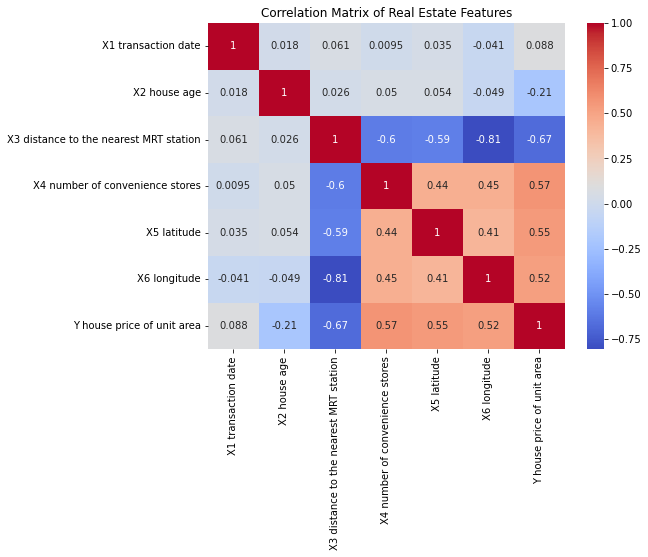

In [7]:
# Correlation Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(real_estate.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Real Estate Features")
plt.show()

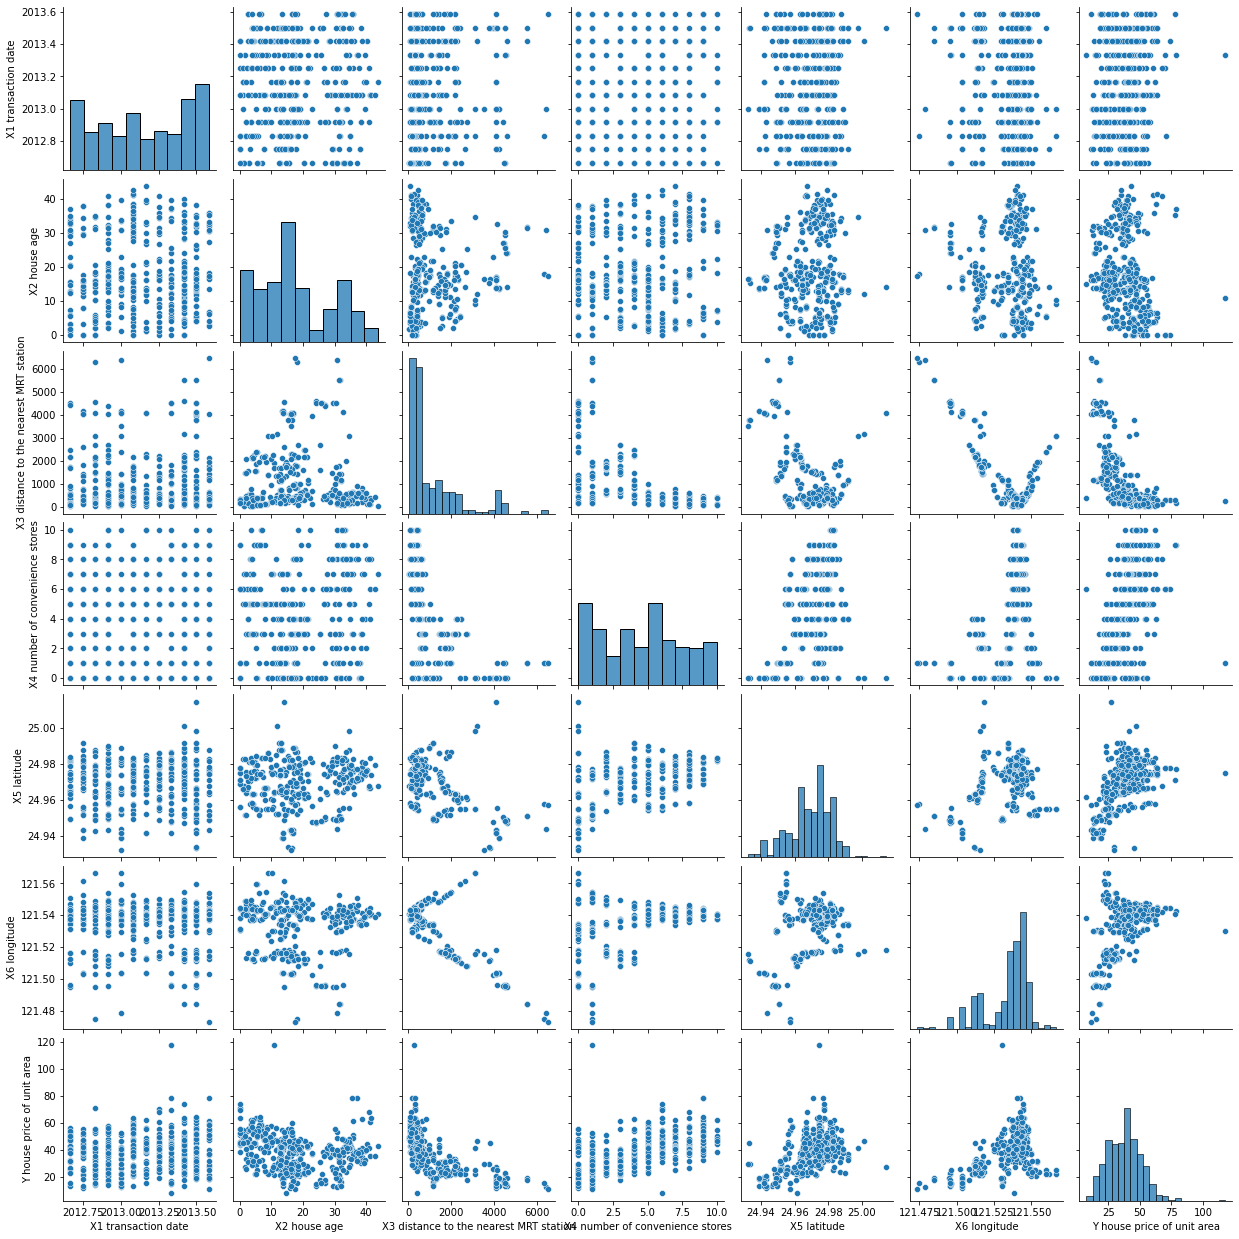

In [8]:
# Pair Plot to see relationships
sns.pairplot(real_estate)
plt.show()

Most feature variables are not that correlated with each other apart from:
- X5 Latitude and X6 Longitude:
    - Seem correlated to
        1. Each other
        2. X3 Distance to the nearest MRT Station (negative correlation)
        3. X4 Number of Convenience Stores
    - A possible explanation for their correlation with each other is that they represent geographic coordinates, which naturally vary together by location. Their correlation with the number of convenience stores and the distance to the nearest MRT station suggests that certain geographic areas (e.g., urban regions) have higher convenience store density and closer proximity to transit options.

### Basic Linear Regression Model

In [9]:
# Define features and target variable
X = real_estate[['X1 transaction date', 'X2 house age', 'X3 distance to the nearest MRT station', 
          'X4 number of convenience stores', 'X5 latitude', 'X6 longitude']]
y = real_estate['Y house price of unit area']

In [10]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

In [11]:
# Standardize features for regularization techniques (optional but recommended)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
# Baseline Linear Regression Model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred = linear_model.predict(X_test)

In [13]:
# Evaluate the baseline model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", round(mse,3))
print("R-squared:", round(r2, 3))

Mean Squared Error: 62.092
R-squared: 0.614


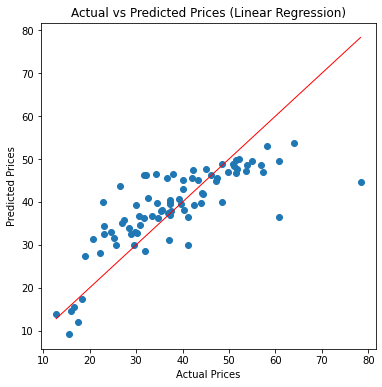

In [14]:
# Plotting the predictions vs actual
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r', lw=1)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices (Linear Regression)")
plt.show()

The graph plots actual house prices against predicted prices from the linear regression model. The closer the points lie to the red line, the more accurate the model; deviations from this line indicate prediction errors. The R2 value is 0.614, which is not enough to call this a very accurate linear regression.

### K-Fold CV

In [15]:
# K-Fold Cross-Validation
kf = KFold(n_splits=6, shuffle=True, random_state=42) # Chose k = 6 since number_of_rows = 414 is divisible by 6, just for convenience
scores = cross_val_score(linear_model, X, y, cv=kf, scoring='neg_mean_squared_error')
print("Cross-Validated MSE:", np.average(np.absolute(scores)))


Cross-Validated MSE: 79.65113192772651


### Ridge Regression with CV

In [16]:
# Ridge Regression with Cross-Validation
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)
ridge_pred = ridge_model.predict(X_test_scaled)
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_r2 = r2_score(y_test, ridge_pred)
print("Mean Squared Error:", round(ridge_mse,3))
print("R-squared:", round(ridge_r2,3))

Mean Squared Error: 62.155
R-squared: 0.614


In [17]:
# Tuning Ridge alpha using Cross-Validation
alphas = np.logspace(-3, 2, 100)
ridge_cv_mse = []
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    cv_mse = cross_val_score(ridge, X_train_scaled, y_train, cv=kf, scoring='neg_mean_squared_error')
    ridge_cv_mse.append(-cv_mse.mean())

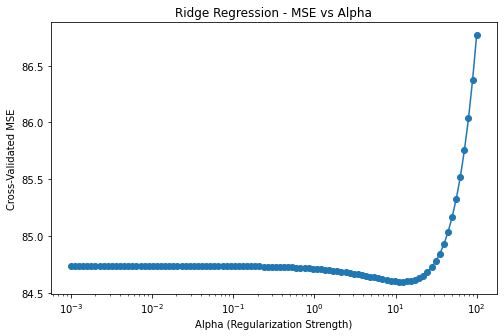

In [18]:
# Plot Ridge CV results
plt.figure(figsize=(8, 5))
plt.plot(alphas, ridge_cv_mse, marker='o')
plt.xscale('log')
plt.xlabel("Alpha (Regularization Strength)")
plt.ylabel("Cross-Validated MSE")
plt.title("Ridge Regression - MSE vs Alpha")
plt.show()

#### Zooming In

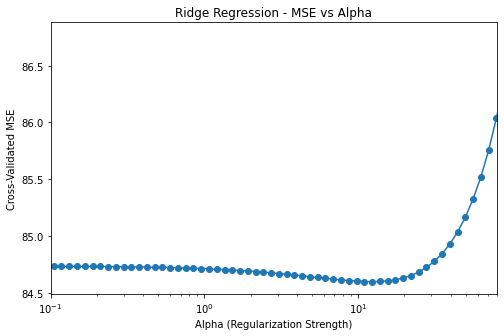

Optimal Alpha: 12.32846739442066


In [19]:
# Plot Ridge CV results
plt.figure(figsize=(8, 5))
plt.plot(alphas, ridge_cv_mse, marker='o')
plt.xscale('log')
plt.xlim(1e-1, 80)
plt.xlabel("Alpha (Regularization Strength)")
plt.ylabel("Cross-Validated MSE")
plt.title("Ridge Regression - MSE vs Alpha")
plt.show()

# Identify the optimal alpha
optimal_alpha = alphas[np.argmin(ridge_cv_mse)]
print("Optimal Alpha:", optimal_alpha)

Here, we can see that alpha = 12 has the lowest MSE.

In [20]:
# Ridge Regression with Cross-Validation
ridge_model = Ridge(alpha=12)
ridge_model.fit(X_train_scaled, y_train)
ridge_pred = ridge_model.predict(X_test_scaled)
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_r2 = r2_score(y_test, ridge_pred)
print("Mean Squared Error:", round(ridge_mse,3))
print("R-squared:", round(ridge_r2,3))

Mean Squared Error: 62.776
R-squared: 0.61


Mean Squared Error (Degree 2): 46.311
R-squared (Degree 2): 0.712


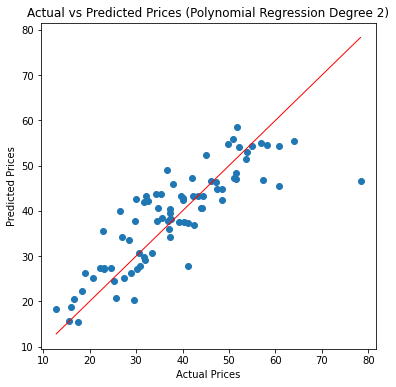

In [21]:
# Apply PolynomialFeatures with degree 2
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Fit Polynomial Regression Model
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# Predict on the test set
y_pred_poly = poly_model.predict(X_test_poly)

# Evaluate the Polynomial Regression Model
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print(f"Mean Squared Error (Degree 2): {round(mse_poly, 3)}")
print(f"R-squared (Degree 2): {round(r2_poly, 3)}")

# Plot Actual vs Predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_poly)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r', lw=1)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices (Polynomial Regression Degree 2)")
plt.show()


So, 

# 2. Classification on Poker Hands

### Description of the data

The Poker Hand dataset is designed to predict the type of poker hand based on five playing cards drawn from a standard 52-card deck. Each record represents a hand, consisting of two attributes for each card (suit and rank), and the task is to classify the hand into one of the 10 possible poker hand types.

- Dataset Characteristics:

    - Type: Multivariate
    - Subject Area: Games / Poker
    - Associated Task: Classification
    - Data Format: Categorical, Integer
    - Number of Instances: 1,025,010 records
    - Number of Features: 10 (excluding the target variable)
    
    
- Features and Target Variable:

    - S1 (int; feature): Suit of card 1 (1-4 representing {Hearts, Spades, Diamonds, Clubs}).
    - C1 (int; feature): Rank of card 1 (1-13 representing Ace, 2, 3, ..., Queen, King).
    - S2 (int; feature): Suit of card 2 (1-4 representing {Hearts, Spades, Diamonds, Clubs}).
    - C2 (int; feature): Rank of card 2 (1-13 representing Ace, 2, 3, ..., Queen, King).
    - S3 (int; feature): Suit of card 3 (1-4 representing {Hearts, Spades, Diamonds, Clubs}).
    - C3 (int; feature): Rank of card 3 (1-13 representing Ace, 2, 3, ..., Queen, King).
    - S4 (int; feature): Suit of card 4 (1-4 representing {Hearts, Spades, Diamonds, Clubs}).
    - C4 (int; feature): Rank of card 4 (1-13 representing Ace, 2, 3, ..., Queen, King).
    - S5 (int; feature): Suit of card 5 (1-4 representing {Hearts, Spades, Diamonds, Clubs}).
    - C5 (int; feature): Rank of card 5 (1-13 representing Ace, 2, 3, ..., Queen, King).
    - CLASS (int; target): Poker hand classification (Ordinal: 0-9, where each value corresponds to a type of poker hand):
        - 0: Nothing in hand (no recognized poker hand).
        - 1: One pair (two cards of the same rank).
        - 2: Two pairs (two different pairs).
        - 3: Three of a kind (three cards of the same rank).
        - 4: Straight (five cards in sequence, no gaps).
        - 5: Flush (five cards of the same suit).
        - 6: Full house (pair + three of a kind).
        - 7: Four of a kind (four cards of the same rank).
        - 8: Straight flush (straight + flush).
        - 9: Royal flush (Ace, King, Queen, Jack, Ten of the same suit).

### Standard Imports

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

### EDA

In [23]:
# Load provided files
train_file = "poker+hand/poker-hand-training-true.data"
test_file = "poker+hand/poker-hand-testing.data"

train_data = pd.read_csv(train_file, header=None,
                         names=["S1", "C1", "S2", "C2", "S3", "C3", "S4", "C4", "S5", "C5", "CLASS"])
test_data = pd.read_csv(test_file, header=None,
                       names=["S1", "C1", "S2", "C2", "S3", "C3", "S4", "C4", "S5", "C5", "CLASS"])

train_data.shape, test_data.shape

((25010, 11), (1000000, 11))

Training data is quite small in comparison to the test data

In [24]:
train_data.isnull().sum()

S1       0
C1       0
S2       0
C2       0
S3       0
C3       0
S4       0
C4       0
S5       0
C5       0
CLASS    0
dtype: int64

In [25]:
train_data.describe()

,S1,C1,S2,C2,S3,C3,S4,C4,S5,C5,CLASS
count,25010.000000,25010.000000,25010.000000,25010.000000,25010.000000,25010.000000,25010.000000,25010.000000,25010.000000,25010.000000,25010.000000
mean,2.508756,6.995242,2.497721,7.014194,2.510236,7.014154,2.495922,6.942463,2.497321,6.962735,0.621152
std,1.116483,3.749805,1.121767,3.766974,1.123148,3.744974,1.116009,3.747147,1.118732,3.741579,0.788361
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,2.000000,4.000000,1.000000,4.000000,2.000000,4.000000,1.000000,4.000000,1.000000,4.000000,0.000000
50%,3.000000,7.000000,2.000000,7.000000,3.000000,7.000000,2.000000,7.000000,3.000000,7.000000,1.000000
75%,4.000000,10.000000,4.000000,10.000000,4.000000,10.000000,3.000000,10.000000,3.000000,10.000000,1.000000
max,4.000000,13.000000,4.000000,13.000000,4.000000,13.000000,4.000000,13.000000,4.000000,13.000000,9.000000


In [26]:
train_data['CLASS'].value_counts()

0    12493
1    10599
2     1206
3      513
4       93
5       54
6       36
7        6
9        5
8        5
Name: CLASS, dtype: int64

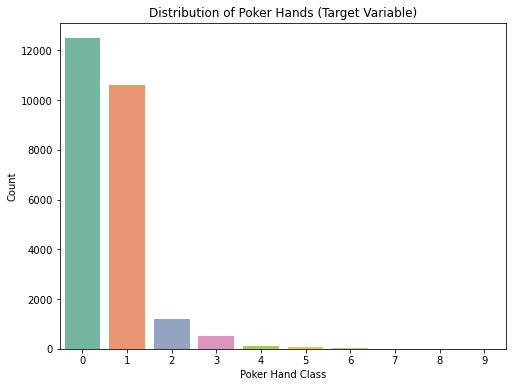

In [27]:
# Visualize the class distribution (target variable)
plt.figure(figsize=(8, 6))
sns.countplot(x="CLASS", data=train_data, palette="Set2")
plt.title("Distribution of Poker Hands (Target Variable)")
plt.xlabel("Poker Hand Class")
plt.ylabel("Count")
plt.show()

It makes sense that the distribution is skewed to the left. Most hands are of CLASS = 0 (no recognized poker hand) or 1 (One Pair - two cards of the same rank) since it's the easiest to get these hands. As the CLASS value increases, the frequency decreases since it's that much harder or uncommon to see such hands.

Since there aren't many samples with CLASS = 4 or above in the training data provided, we will first combine the training and testing data provided by UCI into a single dataset and then split into training and testing.

In [28]:
# Combine train_data and test_data
all_poker_hands = pd.concat([train_data, test_data], ignore_index=True)

# Shuffle the combined data to mix samples from train and test sets
all_poker_hands = all_poker_hands.sample(frac=1, random_state=12).reset_index(drop=True)

all_poker_hands.shape

(1025010, 11)

In [29]:
all_poker_hands.head()

,S1,C1,S2,C2,S3,C3,S4,C4,S5,C5,CLASS
0,4,6,1,12,3,3,2,9,2,5,0
1,4,8,1,13,3,8,2,4,3,7,1
2,3,12,1,11,3,10,2,4,4,10,1
3,2,11,1,9,4,9,3,10,1,2,1
4,4,9,1,2,3,2,1,5,1,7,1


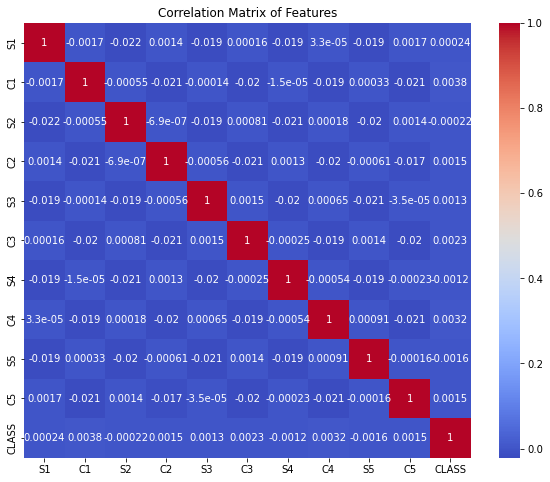

In [30]:
# Check for correlations
corr_matrix = all_poker_hands.corr()

# Plot the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Features")
plt.show()

Again, a correlation matrix would not show much either since the cards you can be dealt is completely random.

### Random Forest Classifier

In [31]:
# Split the data into features (X) and target (y)
X = all_poker_hands.drop(columns=["CLASS"])
y = all_poker_hands["CLASS"]

# Split the dataset into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12, stratify=y)

In [32]:
# Initialize RandomForestClassifier
rf_model = RandomForestClassifier(random_state=12)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.91      0.84    102740
           1       0.72      0.69      0.71     86619
           2       0.62      0.03      0.06      9766
           3       0.83      0.09      0.16      4327
           4       0.56      0.01      0.02       796
           5       0.97      0.17      0.29       410
           6       0.33      0.00      0.01       292
           7       0.00      0.00      0.00        47
           8       0.00      0.00      0.00         3
           9       0.00      0.00      0.00         2

    accuracy                           0.75    205002
   macro avg       0.48      0.19      0.21    205002
weighted avg       0.74      0.75      0.73    205002



~/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
~/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
~/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


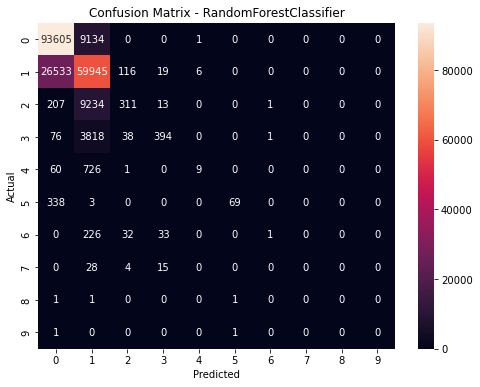

In [33]:
# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt = 'd')
plt.title("Confusion Matrix - RandomForestClassifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

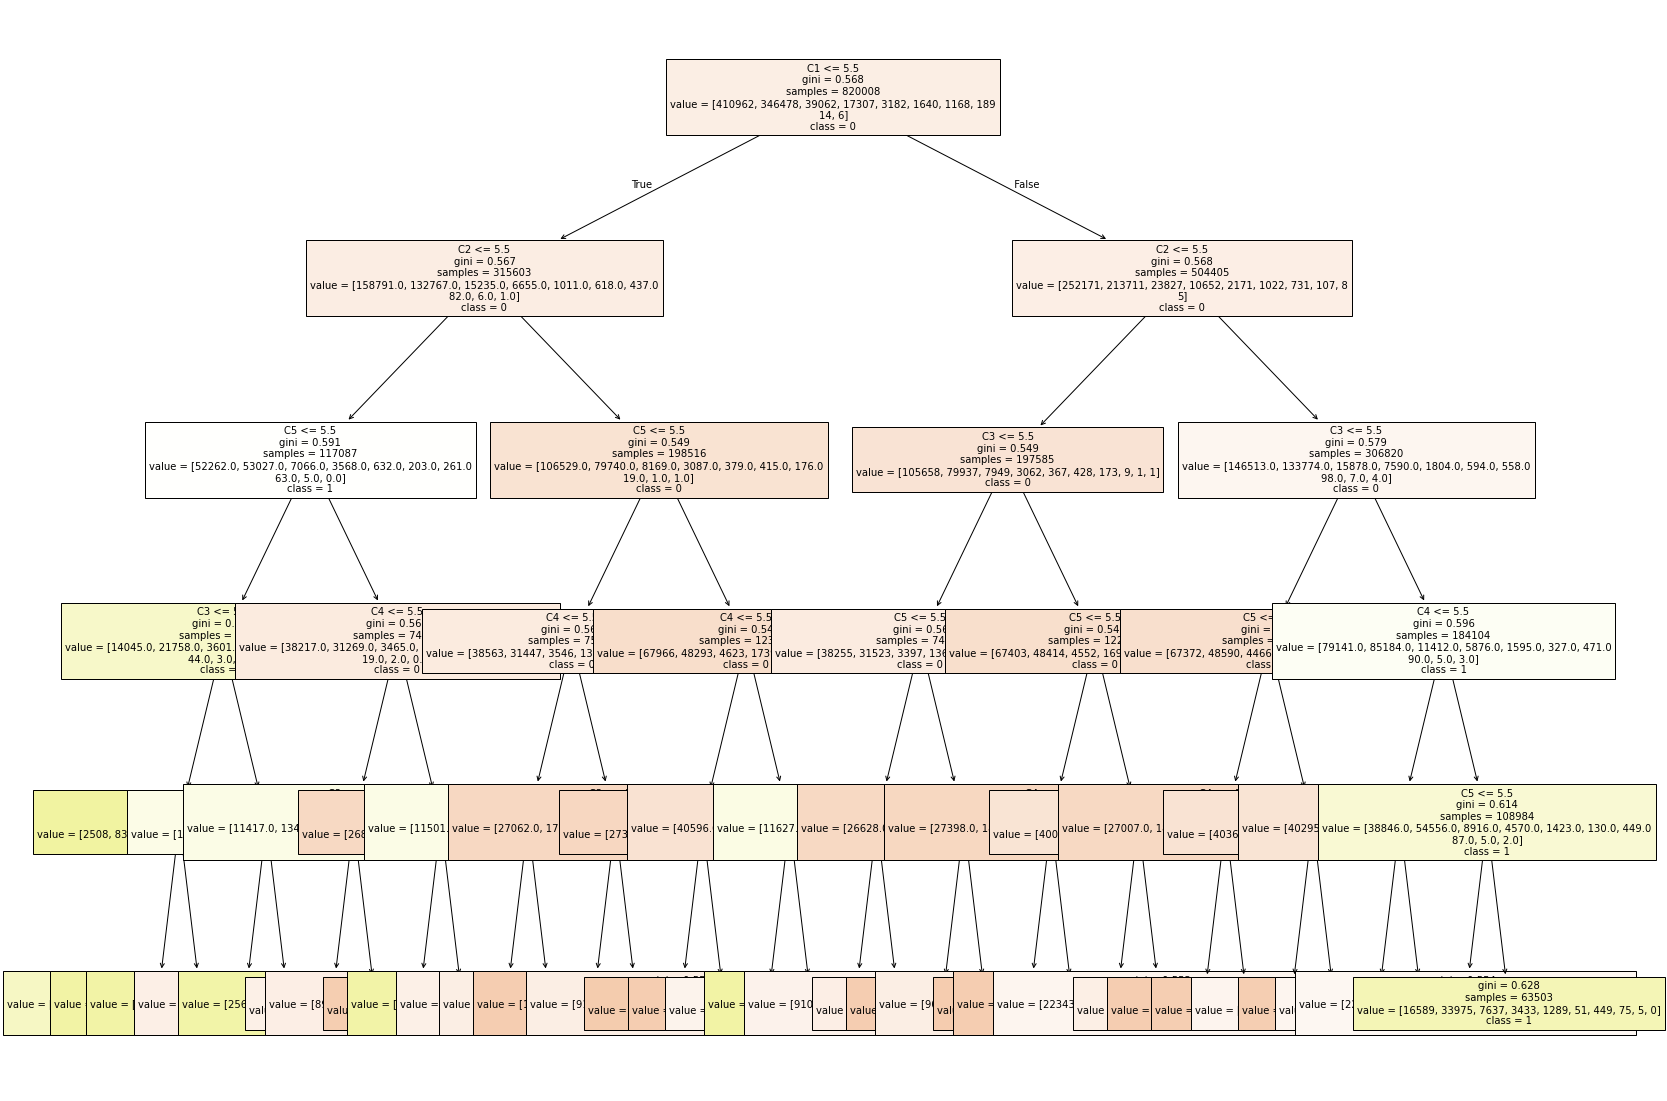

In [38]:
# Initialize and train the decision tree
clf_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
clf_tree.fit(X_train, y_train)

# Predictions on the test set
y_pred = clf_tree.predict(X_test)
# Plot the decision tree
fig = plt.figure(figsize=(25, 20))
_ = tree.plot_tree(clf_tree, feature_names=X.columns, class_names=[str(i) for i in range(10)],
                   filled=True, fontsize=10)
plt.show()

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.93      0.69    102740
           1       0.56      0.19      0.28     86619
           2       0.00      0.00      0.00      9766
           3       0.00      0.00      0.00      4327
           4       0.00      0.00      0.00       796
           5       0.00      0.00      0.00       410
           6       0.00      0.00      0.00       292
           7       0.00      0.00      0.00        47
           8       0.00      0.00      0.00         3
           9       0.00      0.00      0.00         2

    accuracy                           0.54    205002
   macro avg       0.11      0.11      0.10    205002
weighted avg       0.51      0.54      0.46    205002



~/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
~/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
~/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


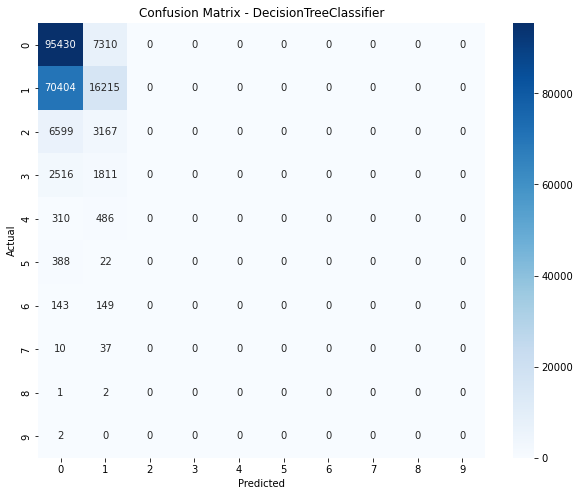

In [39]:
# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix - DecisionTreeClassifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [40]:
# Define parameter grid
param_grid = {
    'max_depth': [3, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

# Grid search with cross-validation
grid_search = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42),
                           param_grid=param_grid,
                           scoring='accuracy',
                           cv=5, verbose=2, n_jobs=-1)

grid_search.fit(X_train, y_train)

# Best parameters
print("Best Hyperparameters:", grid_search.best_params_)

# Train the optimized model
best_clf_tree = grid_search.best_estimator_
y_pred_optimized = best_clf_tree.predict(X_test)

# Evaluate the optimized model
print("Classification Report (Optimized):")
print(classification_report(y_test, y_pred_optimized))


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Hyperparameters: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2}
Classification Report (Optimized):
              precision    recall  f1-score   support

           0       0.69      0.75      0.72    102740
           1       0.59      0.58      0.58     86619
           2       0.31      0.18      0.23      9766
           3       0.46      0.24      0.31      4327
           4       0.28      0.12      0.17       796
           5       0.61      0.21      0.31       410
           6       0.29      0.09      0.14       292
           7       0.22      0.04      0.07        47
           8       0.00      0.00      0.00         3
           9       0.00      0.00      0.00         2

    accuracy                           0.63    205002
   macro avg       0.35      0.22      0.25    205002
weighted avg       0.62      0.63      0.63    205002



~/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
~/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
~/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


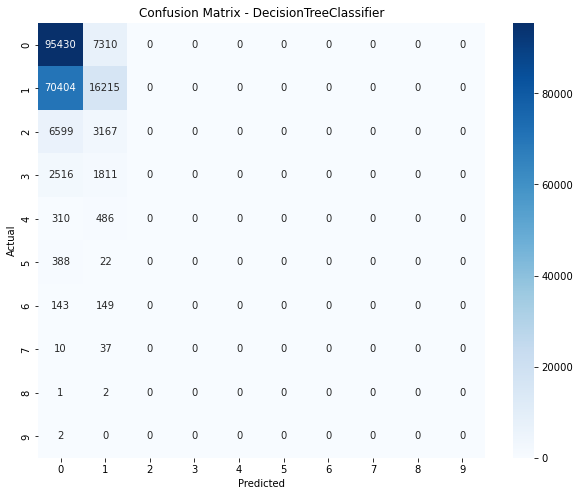

[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=5; total time=   1.8s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=5; total time=   1.5s
[CV] END max_depth=3, min_samples_leaf=2, min_samples_split=2; total time=   1.3s
[CV] END max_depth=3, min_samples_leaf=2, min_samples_split=10; total time=   1.1s
[CV] END max_depth=3, min_samples_leaf=4, min_samples_split=2; total time=   1.2s
[CV] END max_depth=3, min_samples_leaf=4, min_samples_split=10; total time=   1.1s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=5; total time=   1.6s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=10; total time=   1.7s
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=2; total time=   1.7s
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=10; total time=   1.7s
[CV] END max_depth=5, min_samples_leaf=4, min_samples_split=5; total time=   2.0s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2; total time=   3.2s
[CV] END ma

[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2; total time=   2.0s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=10; total time=   1.4s
[CV] END max_depth=3, min_samples_leaf=2, min_samples_split=5; total time=   1.4s
[CV] END max_depth=3, min_samples_leaf=4, min_samples_split=2; total time=   1.2s
[CV] END max_depth=3, min_samples_leaf=4, min_samples_split=5; total time=   1.3s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2; total time=   1.7s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=5; total time=   1.8s
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=2; total time=   1.6s
[CV] END max_depth=5, min_samples_leaf=2, min_samples_split=5; total time=   1.9s
[CV] END max_depth=5, min_samples_leaf=4, min_samples_split=2; total time=   1.9s
[CV] END max_depth=5, min_samples_leaf=4, min_samples_split=10; total time=   1.9s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5; total time=   3.0s
[CV] END max_

In [41]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix - DecisionTreeClassifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()